# Análise Exploratória e Justificativa de Features
## Previsão de Ações do Setor de Energia com LSTM

**Carteira:** XOM, CVX, SLB, HAL — NYSE  
**Objetivo:** Justificar empiricamente a seleção de features através de análise de correlação, estacionariedade e poder preditivo.

---
### Estrutura do notebook
1. Instalação e imports
2. Coleta de dados
3. Estacionariedade — por que log-return e não preço bruto
4. Cálculo de todas as features candidatas com `pandas-ta`
5. Matriz de correlação — identificação de redundâncias
6. Poder preditivo de cada feature (Mutual Information)
7. Correlação cruzada entre os 4 ativos
8. Distribuição das features selecionadas
9. Conclusão — conjunto final justificado

---
## 1. Instalação e Imports

In [1]:
#!pip install yfinance pandas-ta scikit-learn seaborn matplotlib scipy statsmodels

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf
import pandas_ta as ta

from scipy import stats
from statsmodels.tsa.stattools import adfuller
from sklearn.feature_selection import mutual_info_regression

# ── Helper para detecção automática de colunas do pandas-ta ──────────────────
#
# O pandas-ta nomeia colunas incluindo os parâmetros usados:
#   ta.bbands() → 'BBP_20_2.0', 'BBU_20_2.0', 'BBL_20_2.0'
#   ta.macd()   → 'MACDh_12_26_9', 'MACD_12_26_9'
#   ta.stoch()  → 'STOCHk_14_3_3', 'STOCHd_14_3_3'
#
# Esses nomes mudam entre versões da biblioteca.
# get_col() detecta o nome correto em tempo de execução.

def get_col(df, prefix):
    """Retorna o nome da primeira coluna que começa com o prefixo dado."""
    cols = [c for c in df.columns if str(c).startswith(prefix)]
    if not cols:
        raise KeyError(
            f"Nenhuma coluna com prefixo '{prefix}' encontrada.\n"
            f"Colunas disponíveis: {list(df.columns)}"
        )
    return cols[0]

# ── Estilo visual ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.size':        11,
})

CORES = {
    'XOM': '#1D9E75',
    'CVX': '#534AB7',
    'SLB': '#D85A30',
    'HAL': '#BA7517',
}

print(f'pandas-ta version: {ta.version}')
print('Imports OK')

pandas-ta version: 0.4.71b0
Imports OK


---
## 2. Coleta de Dados

In [2]:
TICKERS_ATIVOS = ['XOM', 'CVX', 'SLB', 'HAL']
TICKERS_MACRO  = ['CL=F', 'BZ=F', 'NG=F']

# Períodos excluindo pandemia (2019–2022)
PERIODOS = [('2010-01-01', '2018-12-31'), ('2023-01-01', '2024-12-31')]

def baixar_concat(tickers, periodos):
    """Baixa dados do yfinance e concatena os dois períodos."""
    partes = []
    for start, end in periodos:
        df = yf.download(tickers, start=start, end=end,
                         auto_adjust=True, progress=False)
        partes.append(df)
    return pd.concat(partes).sort_index()

raw_ativos = baixar_concat(TICKERS_ATIVOS, PERIODOS)
raw_macro  = baixar_concat(TICKERS_MACRO,  PERIODOS)

print('Colunas (nível 0):', raw_ativos.columns.get_level_values(0).unique().tolist())
print(f'Dias — Ativos: {len(raw_ativos)}  |  Macro: {len(raw_macro)}')
print(f'Período: {raw_ativos.index[0].date()} → {raw_ativos.index[-1].date()}')
raw_ativos['Close'].tail(3)

/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4War

Colunas (nível 0): ['Close', 'High', 'Low', 'Open', 'Volume']
Dias — Ativos: 2764  |  Macro: 2763
Período: 2010-01-04 → 2024-12-30


Ticker,CVX,HAL,SLB,XOM
Date,,,,
2024-12-26,136.268204,25.901241,36.357758,102.039902
2024-12-27,136.287140,25.891575,36.425213,102.030319
2024-12-30,135.406967,26.055874,36.434849,101.340416


---
## 3. Estacionariedade — Por que Log-Return e não Preço Bruto?

Uma série temporal é **estacionária** quando média e variância são constantes ao longo do tempo.  
LSTMs assumem estacionariedade implicitamente — treinar com preço bruto significa aprender padrões válidos apenas para uma faixa de preço que pode nunca se repetir.

**Teste ADF (Augmented Dickey-Fuller):**
- `p > 0.05` → não estacionária ✗  
- `p < 0.05` → estacionária ✓

In [3]:
def teste_adf(serie, nome):
    p = adfuller(serie.dropna())[1]
    status = 'ESTACIONÁRIA  ✓' if p < 0.05 else 'NÃO ESTACIONÁRIA ✗'
    print(f'  {nome:<28} p = {p:.4f}  →  {status}')
    return p

print('=== Teste ADF: Preço Bruto vs Log-Return ===')
for ticker in TICKERS_ATIVOS:
    close  = raw_ativos['Close'][ticker].dropna()
    logret = np.log(close / close.shift(1)).dropna()
    print(f'\n{ticker}')
    teste_adf(close,  'Preço bruto')
    teste_adf(logret, 'Log-return')

=== Teste ADF: Preço Bruto vs Log-Return ===

XOM
  Preço bruto                  p = 0.7269  →  NÃO ESTACIONÁRIA ✗
  Log-return                   p = 0.0000  →  ESTACIONÁRIA  ✓

CVX
  Preço bruto                  p = 0.7376  →  NÃO ESTACIONÁRIA ✗
  Log-return                   p = 0.0000  →  ESTACIONÁRIA  ✓

SLB
  Preço bruto                  p = 0.0775  →  NÃO ESTACIONÁRIA ✗
  Log-return                   p = 0.0000  →  ESTACIONÁRIA  ✓

HAL
  Preço bruto                  p = 0.0583  →  NÃO ESTACIONÁRIA ✗
  Log-return                   p = 0.0000  →  ESTACIONÁRIA  ✓


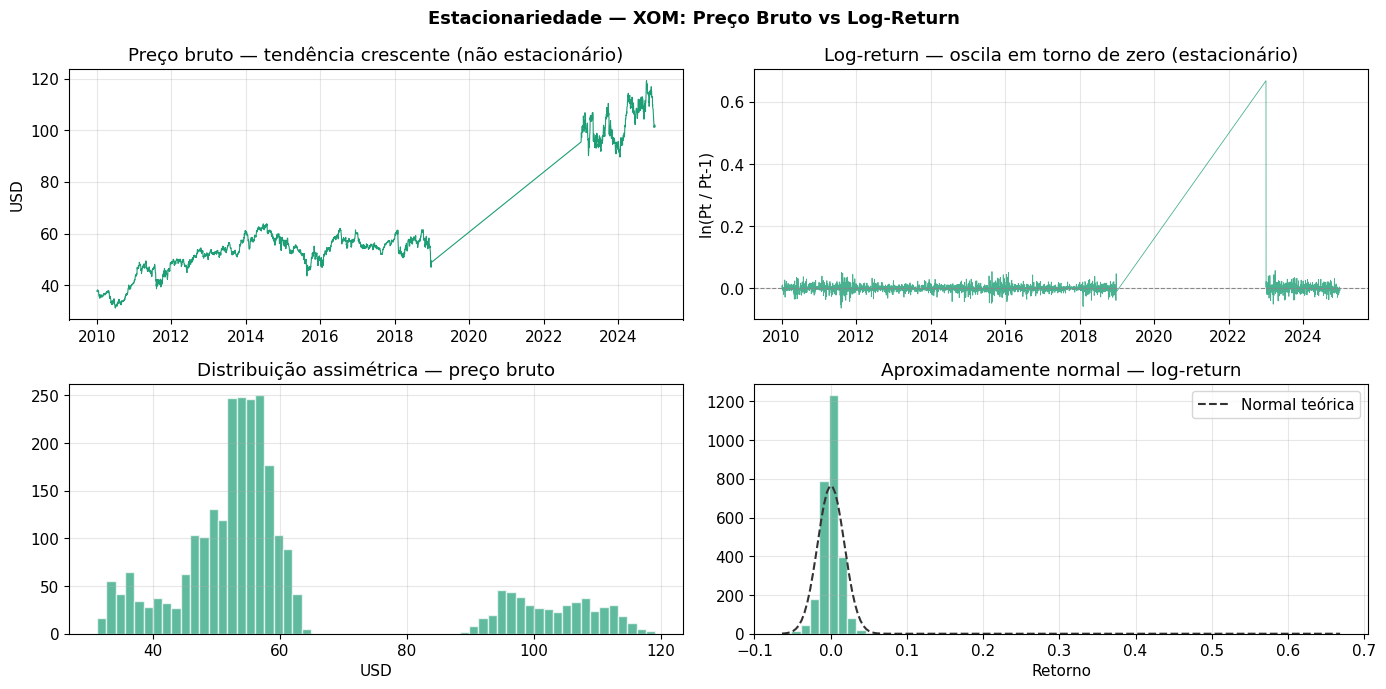

In [4]:
# Visualização comparativa para XOM
ticker = 'XOM'
close  = raw_ativos['Close'][ticker].dropna()
logret = np.log(close / close.shift(1)).dropna()

fig, axes = plt.subplots(2, 2, figsize=(14, 7))
fig.suptitle(f'Estacionariedade — {ticker}: Preço Bruto vs Log-Return',
             fontsize=13, fontweight='bold')

axes[0,0].plot(close.index, close.values, color=CORES[ticker], linewidth=0.8)
axes[0,0].set_title('Preço bruto — tendência crescente (não estacionário)')
axes[0,0].set_ylabel('USD')

axes[0,1].plot(logret.index, logret.values, color=CORES[ticker], linewidth=0.6, alpha=0.8)
axes[0,1].axhline(0, color='#888', linewidth=0.8, linestyle='--')
axes[0,1].set_title('Log-return — oscila em torno de zero (estacionário)')
axes[0,1].set_ylabel('ln(Pt / Pt-1)')

axes[1,0].hist(close.values, bins=60, color=CORES[ticker], alpha=0.7, edgecolor='white')
axes[1,0].set_title('Distribuição assimétrica — preço bruto')
axes[1,0].set_xlabel('USD')

axes[1,1].hist(logret.values, bins=60, color=CORES[ticker], alpha=0.7, edgecolor='white')
x = np.linspace(logret.min(), logret.max(), 200)
axes[1,1].plot(x,
    stats.norm.pdf(x, logret.mean(), logret.std()) * len(logret) * (logret.max()-logret.min())/60,
    color='#333', linewidth=1.5, linestyle='--', label='Normal teórica')
axes[1,1].set_title('Aproximadamente normal — log-return')
axes[1,1].set_xlabel('Retorno')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('estacionariedade.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Cálculo das Features com `pandas-ta`

`pandas-ta` é uma biblioteca de análise técnica que calcula mais de 130 indicadores diretamente sobre Series do pandas.  
Usamos `get_col(df, prefix)` para detectar nomes de colunas independente da versão instalada.

In [5]:
def calcular_features(ticker, raw_ativos, raw_macro):
    """
    Calcula todas as features candidatas usando pandas-ta.
    Divide em: selecionadas (entram no modelo) e candidatas (para análise de redundância).
    """
    df = pd.DataFrame(index=raw_ativos.index)

    close  = raw_ativos['Close'][ticker]
    open_  = raw_ativos['Open'][ticker]
    high   = raw_ativos['High'][ticker]
    low    = raw_ativos['Low'][ticker]
    volume = raw_ativos['Volume'][ticker]

    # ── PREÇO E RETORNO ───────────────────────────────────────────────────────
    df['logret_close'] = np.log(close / close.shift(1))
    df['logret_open']  = np.log(open_ / close.shift(1))   # gap overnight

    # ── VOLUME ────────────────────────────────────────────────────────────────
    df['volume_ratio'] = volume / volume.rolling(20).mean()

    # OBV — pandas-ta: acumula volume com direção do preço
    obv = ta.obv(close, volume)
    df['obv_diff'] = obv.diff() / volume   # variação diária normalizada

    # ── TENDÊNCIA ─────────────────────────────────────────────────────────────
    sma50  = ta.sma(close, length=50)
    sma200 = ta.sma(close, length=200)
    ema12  = ta.ema(close, length=12)
    ema26  = ta.ema(close, length=26)

    # Features selecionadas: diferenças normalizadas
    df['sma_diff'] = (sma50 - sma200) / sma200   # regime bull/bear
    df['ema_diff'] = (ema12 - ema26)  / close     # tendência curto prazo

    # Candidatas à análise de redundância
    df['sma20_r']  = ta.sma(close, length=20) / close
    df['sma50_r']  = sma50  / close
    df['sma200_r'] = sma200 / close
    df['ema12_r']  = ema12  / close
    df['ema26_r']  = ema26  / close

    # ── MOMENTUM ─────────────────────────────────────────────────────────────
    # RSI — pandas-ta retorna série diretamente (já em 0–100)
    df['rsi14'] = ta.rsi(close, length=14)

    # MACD — get_col detecta 'MACDh_12_26_9' independente da versão
    macd_df = ta.macd(close, fast=12, slow=26, signal=9)
    df['macd_hist'] = macd_df[get_col(macd_df, 'MACDh')] / close
    df['macd_line'] = macd_df[get_col(macd_df, 'MACD_')] / close   # candidata

    # Estocástico — candidata (verificar redundância com RSI)
    stoch_df = ta.stoch(high, low, close)
    df['stoch_k'] = stoch_df[get_col(stoch_df, 'STOCHk')]
    df['stoch_d'] = stoch_df[get_col(stoch_df, 'STOCHd')]

    # Williams %R — candidata (verificar redundância com RSI)
    df['williams_r'] = ta.willr(high, low, close, length=14)

    # CCI e ROC — candidatas
    df['cci'] = ta.cci(high, low, close, length=20)
    df['roc'] = ta.roc(close, length=10)

    # ── VOLATILIDADE ──────────────────────────────────────────────────────────
    df['atr14'] = ta.atr(high, low, close, length=14) / close

    # Bollinger — get_col evita KeyError por versão
    bb = ta.bbands(close, length=20, std=2)
    df['bb_pct_b'] = bb[get_col(bb, 'BBP')]   # posição no canal (0–1)
    df['bb_width'] = (bb[get_col(bb, 'BBU')] - bb[get_col(bb, 'BBL')]) / close

    df['vol_hist'] = df['logret_close'].rolling(20).std()   # candidata

    # ── MACRO ─────────────────────────────────────────────────────────────────
    wti = np.log(raw_macro['Close']['CL=F'] / raw_macro['Close']['CL=F'].shift(1))
    brt = np.log(raw_macro['Close']['BZ=F'] / raw_macro['Close']['BZ=F'].shift(1))
    ng  = np.log(raw_macro['Close']['NG=F'] / raw_macro['Close']['NG=F'].shift(1))

    df['wti_logret']   = wti
    df['brent_logret'] = brt
    df['ng_logret']    = ng
    df['spread_wb']    = wti - brt   # desequilíbrio regional de oferta

    # ── TARGET: retorno do DIA SEGUINTE ───────────────────────────────────────
    df['target'] = df['logret_close'].shift(-1)

    return df.dropna()


features_ativos = {}
for ticker in TICKERS_ATIVOS:
    features_ativos[ticker] = calcular_features(ticker, raw_ativos, raw_macro)
    n = features_ativos[ticker].shape
    print(f'{ticker}: {n[0]} amostras, {n[1]-1} features + target')

print('\nColunas geradas (XOM):')
print(features_ativos['XOM'].columns.tolist())

XOM: 2505 amostras, 27 features + target
CVX: 2505 amostras, 27 features + target
SLB: 2505 amostras, 27 features + target
HAL: 2505 amostras, 27 features + target

Colunas geradas (XOM):
['logret_close', 'logret_open', 'volume_ratio', 'obv_diff', 'sma_diff', 'ema_diff', 'sma20_r', 'sma50_r', 'sma200_r', 'ema12_r', 'ema26_r', 'rsi14', 'macd_hist', 'macd_line', 'stoch_k', 'stoch_d', 'williams_r', 'cci', 'roc', 'atr14', 'bb_pct_b', 'bb_width', 'vol_hist', 'wti_logret', 'brent_logret', 'ng_logret', 'spread_wb', 'target']


---
## 5. Matriz de Correlação — Identificação de Redundâncias

Features com `|r| > 0.90` transmitem informação quase idêntica. Mantê-las aumenta a complexidade sem ganho preditivo.

In [6]:
ticker = 'XOM'
df_xom = features_ativos[ticker]
cols   = [c for c in df_xom.columns if c != 'target']
corr   = df_xom[cols].corr()

print(f'=== Pares com |r| > 0.90 — {ticker} ===')
pares = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > 0.90:
            f1, f2 = corr.columns[i], corr.columns[j]
            pares.append((f1, f2, r))
            print(f'  {f1:<22} ↔  {f2:<22}  r = {r:+.3f}')

print(f'\nTotal de pares redundantes: {len(pares)}')

=== Pares com |r| > 0.90 — XOM ===
  ema_diff               ↔  sma50_r                 r = -0.955
  ema_diff               ↔  macd_line               r = +1.000
  sma20_r                ↔  ema12_r                 r = +0.955
  sma20_r                ↔  ema26_r                 r = +0.968
  sma50_r                ↔  ema26_r                 r = +0.929
  sma50_r                ↔  macd_line               r = -0.955
  ema12_r                ↔  ema26_r                 r = +0.934
  stoch_k                ↔  stoch_d                 r = +0.958
  stoch_k                ↔  williams_r              r = +0.916
  williams_r             ↔  bb_pct_b                r = +0.932
  wti_logret             ↔  brent_logret            r = +0.907

Total de pares redundantes: 11


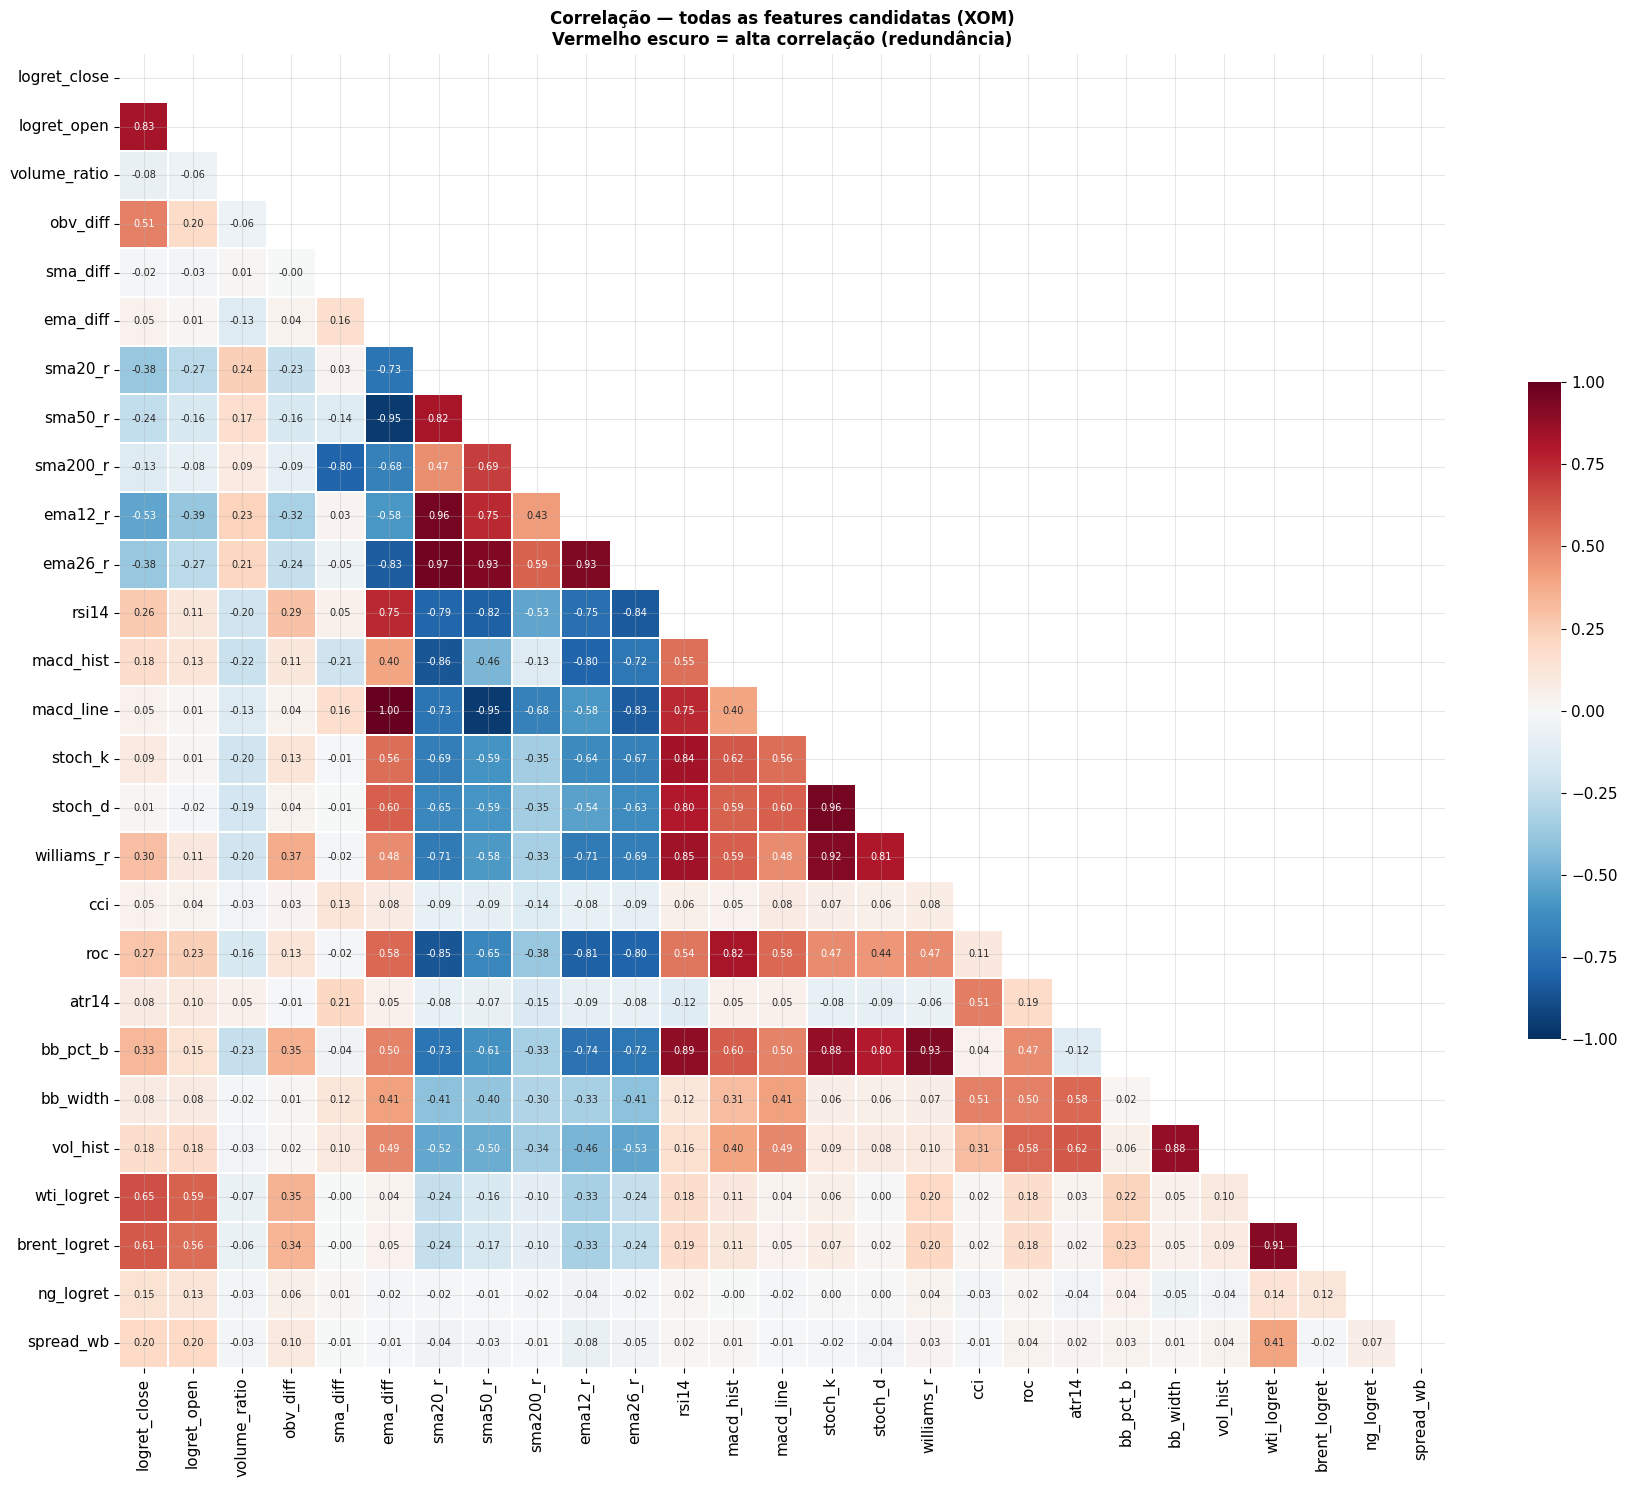

In [7]:
# Heatmap — todas as features candidatas
fig, ax = plt.subplots(figsize=(18, 15))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 7},
            linewidths=0.3, linecolor='white', cbar_kws={'shrink': 0.5})
ax.set_title(f'Correlação — todas as features candidatas ({ticker})\n'
             'Vermelho escuro = alta correlação (redundância)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'correlacao_candidatas_{ticker}.png', dpi=150, bbox_inches='tight')
plt.show()

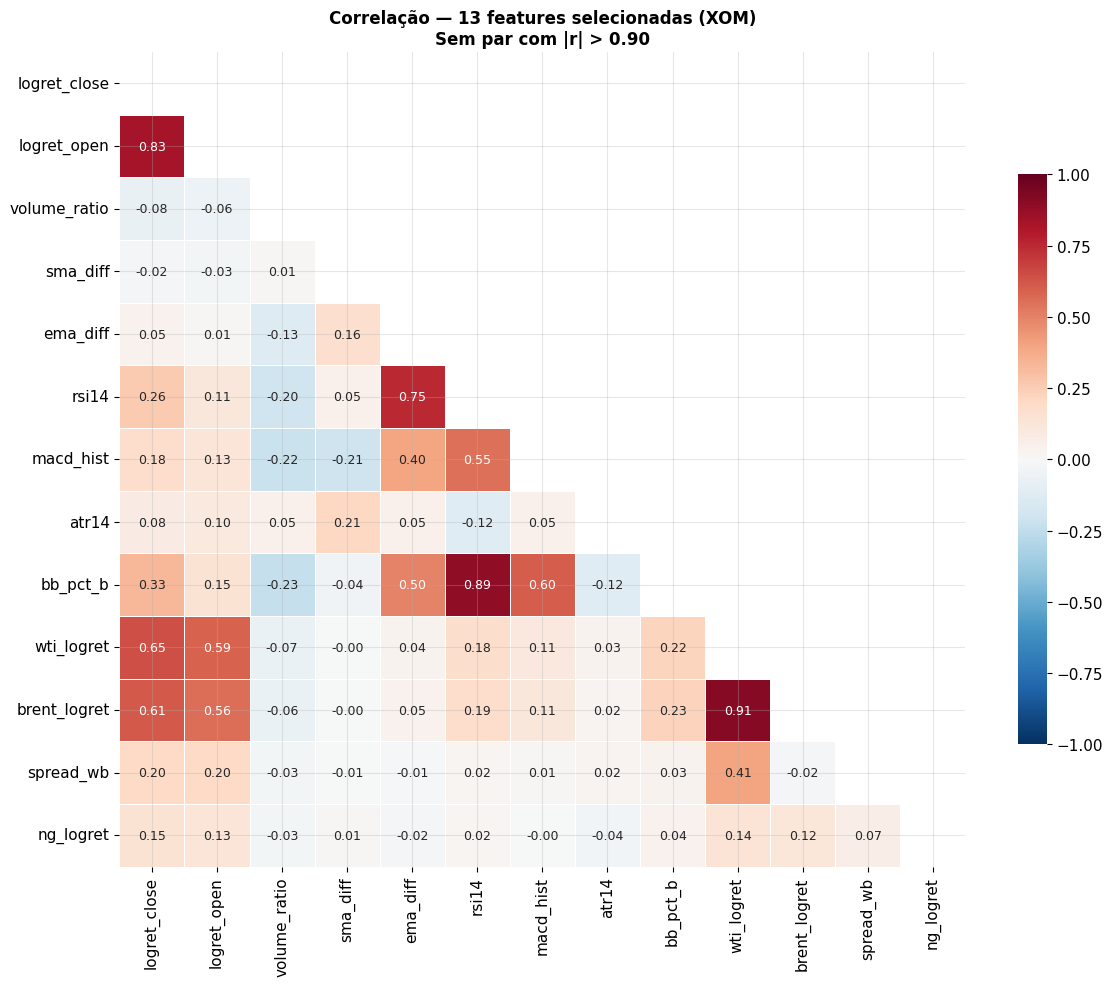

Maior correlação no conjunto final: 0.907  ('brent_logret', 'wti_logret')


In [8]:
# Heatmap — apenas as 13 features selecionadas
FEATURES_FINAIS = [
    'logret_close', 'logret_open', 'volume_ratio',
    'sma_diff', 'ema_diff',
    'rsi14', 'macd_hist',
    'atr14', 'bb_pct_b',
    'wti_logret', 'brent_logret', 'spread_wb', 'ng_logret'
]

corr_final  = df_xom[FEATURES_FINAIS].corr()
mask_final  = np.triu(np.ones_like(corr_final, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_final, mask=mask_final, ax=ax,
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 9},
            linewidths=0.5, linecolor='white', cbar_kws={'shrink': 0.7})
ax.set_title(f'Correlação — 13 features selecionadas ({ticker})\n'
             'Sem par com |r| > 0.90', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'correlacao_selecionadas_{ticker}.png', dpi=150, bbox_inches='tight')
plt.show()

max_r = corr_final.where(~mask_final).abs().stack().sort_values(ascending=False)
print(f'Maior correlação no conjunto final: {max_r.iloc[0]:.3f}  {max_r.index[0]}')

---
## 6. Poder Preditivo — Mutual Information com o Target

**Mutual Information (MI)** mede quanto cada feature reduz a incerteza sobre o retorno do dia seguinte.  
Ao contrário da correlação de Pearson, captura relações **não-lineares** — mais adequado para avaliar features em uma LSTM.  
Features com MI próximo de zero são essencialmente ruído para o modelo.

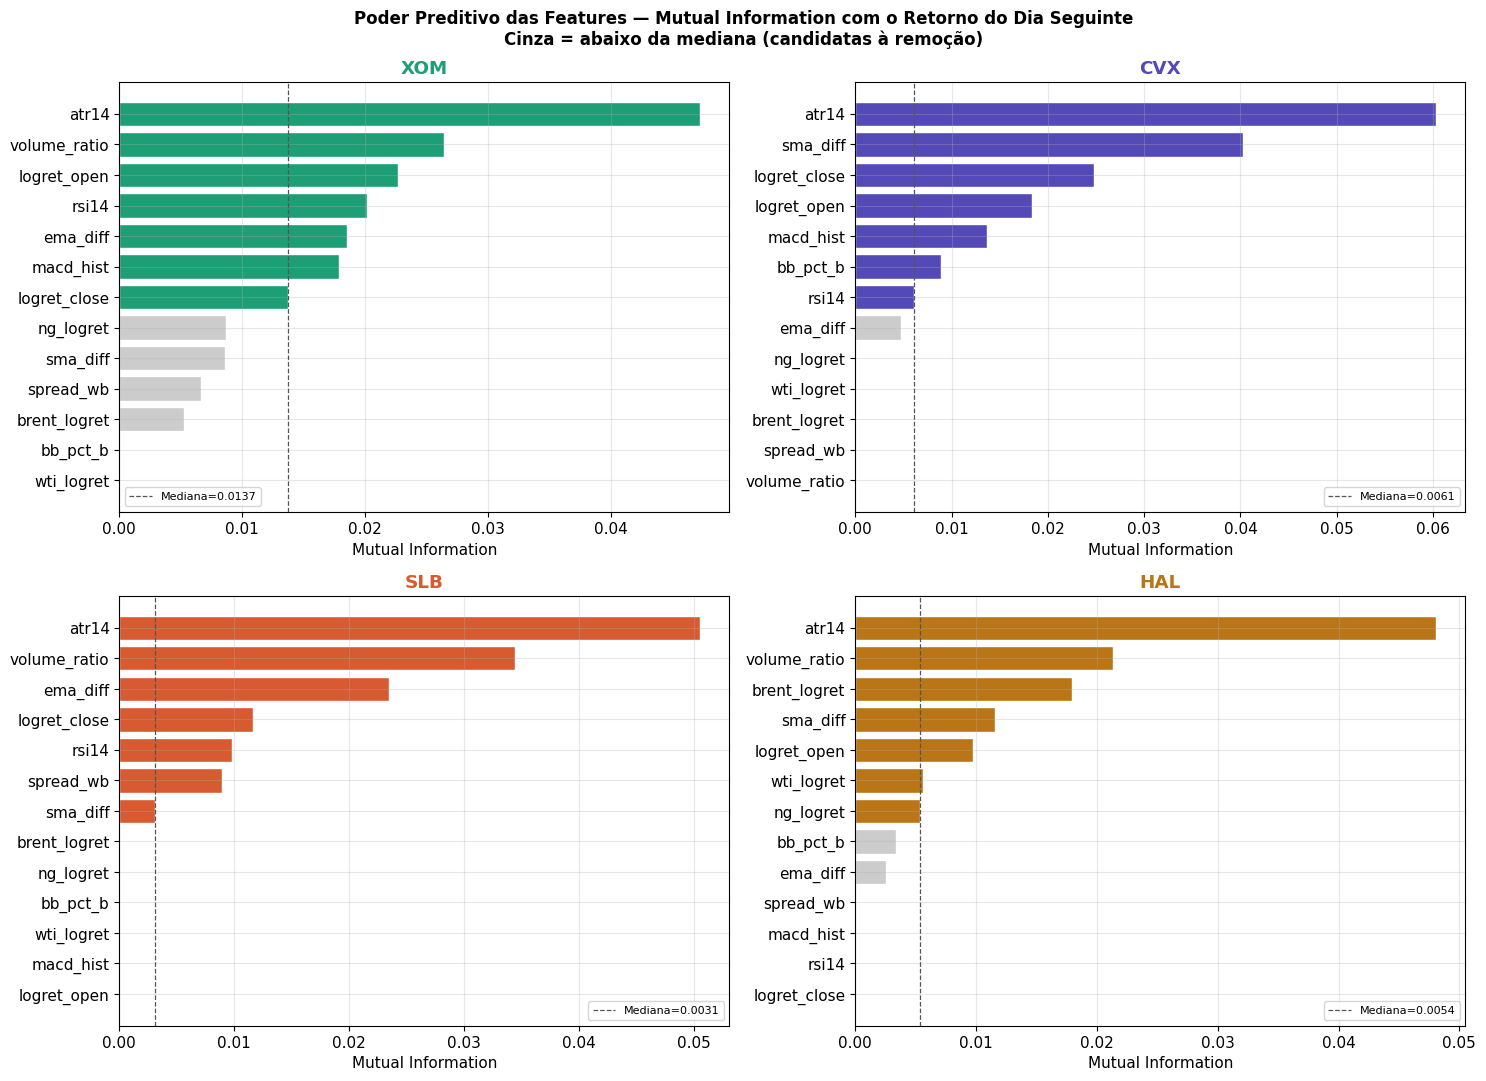

In [9]:
resultados_mi = {}
for ticker in TICKERS_ATIVOS:
    df = features_ativos[ticker]
    X  = df[FEATURES_FINAIS].values
    y  = df['target'].values
    mi = mutual_info_regression(X, y, random_state=42)
    pearson = [stats.pearsonr(X[:, i], y)[0] for i in range(X.shape[1])]
    resultados_mi[ticker] = pd.DataFrame({
        'feature': FEATURES_FINAIS,
        'MI':      mi,
        'pearson': pearson
    }).sort_values('MI', ascending=True)

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Poder Preditivo das Features — Mutual Information com o Retorno do Dia Seguinte\n'
             'Cinza = abaixo da mediana (candidatas à remoção)',
             fontsize=12, fontweight='bold')

for ax, ticker in zip(axes.flat, TICKERS_ATIVOS):
    res     = resultados_mi[ticker]
    med     = res['MI'].median()
    cores_b = [CORES[ticker] if v >= med else '#cccccc' for v in res['MI']]
    ax.barh(res['feature'], res['MI'], color=cores_b, edgecolor='white')
    ax.axvline(med, color='#555', linestyle='--', linewidth=0.9, label=f'Mediana={med:.4f}')
    ax.set_title(ticker, fontweight='bold', color=CORES[ticker])
    ax.set_xlabel('Mutual Information')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('mutual_information.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Ranking médio de MI entre os 4 ativos
mi_medio = pd.DataFrame({
    t: resultados_mi[t].set_index('feature')['MI'] for t in TICKERS_ATIVOS
}).mean(axis=1).sort_values(ascending=False)

print('=== Ranking médio de Mutual Information — 4 ativos ===')
for feat, mi in mi_medio.items():
    barra = '█' * int(mi / mi_medio.max() * 35)
    print(f'  {feat:<20} {barra:<35} {mi:.5f}')

=== Ranking médio de Mutual Information — 4 ativos ===
  atr14                ███████████████████████████████████ 0.05156
  volume_ratio         █████████████                       0.02053
  sma_diff             ██████████                          0.01586
  logret_open          ████████                            0.01266
  logret_close         ████████                            0.01254
  ema_diff             ████████                            0.01234
  rsi14                ██████                              0.00903
  macd_hist            █████                               0.00788
  brent_logret         ███                                 0.00579
  spread_wb            ██                                  0.00388
  ng_logret            ██                                  0.00352
  bb_pct_b             ██                                  0.00306
  wti_logret                                               0.00140


---
## 7. Correlação Cruzada entre os 4 Ativos

Justifica treinar o modelo de forma **multivariada**: os ativos são correlacionados (mesmo ciclo do petróleo) mas com divergências exploráveis — especialmente entre integradas (XOM, CVX) e prestadores de serviços (SLB, HAL).

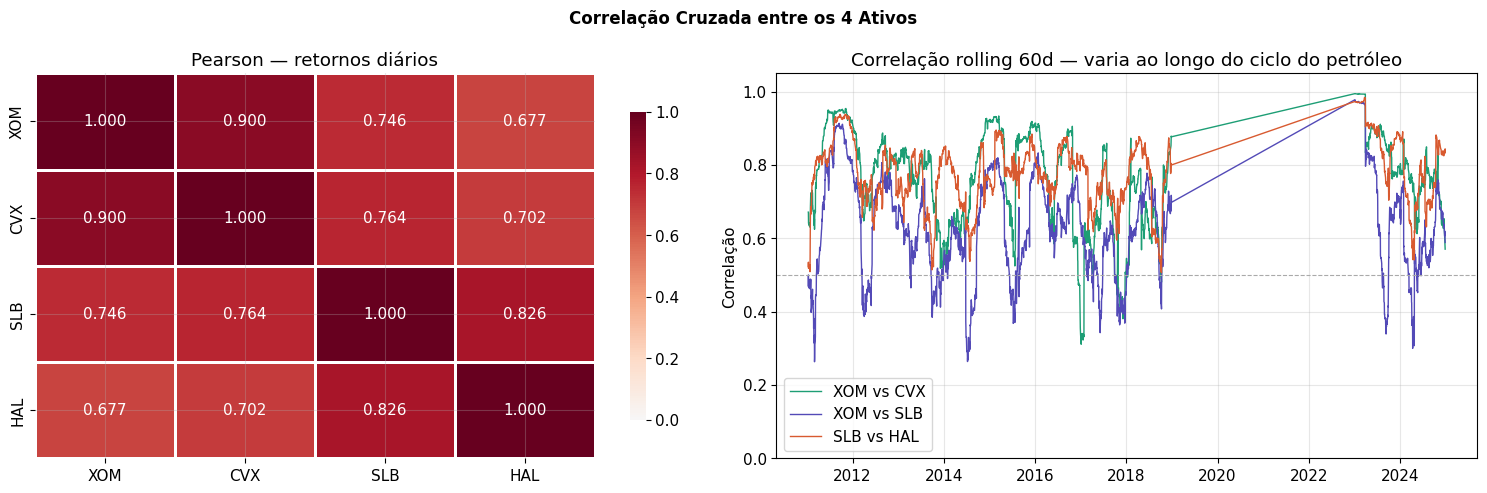

       XOM    CVX    SLB    HAL
XOM  1.000  0.900  0.746  0.677
CVX  0.900  1.000  0.764  0.702
SLB  0.746  0.764  1.000  0.826
HAL  0.677  0.702  0.826  1.000


In [11]:
returns = pd.DataFrame({
    t: features_ativos[t]['logret_close'] for t in TICKERS_ATIVOS
}).dropna()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Correlação Cruzada entre os 4 Ativos', fontsize=12, fontweight='bold')

corr_ativos = returns.corr()
sns.heatmap(corr_ativos, ax=axes[0], annot=True, fmt='.3f',
            cmap='RdBu_r', center=0, vmin=0, vmax=1,
            linewidths=1, linecolor='white', cbar_kws={'shrink': 0.8})
axes[0].set_title('Pearson — retornos diários')

pares_plot = [('XOM', 'CVX'), ('XOM', 'SLB'), ('SLB', 'HAL')]
cores_plot = ['#1D9E75', '#534AB7', '#D85A30']
for (t1, t2), cor in zip(pares_plot, cores_plot):
    rc = returns[t1].rolling(60).corr(returns[t2])
    axes[1].plot(rc.index, rc.values, color=cor, linewidth=1, label=f'{t1} vs {t2}')
axes[1].axhline(0.5, color='#aaa', linestyle='--', linewidth=0.8)
axes[1].set_title('Correlação rolling 60d — varia ao longo do ciclo do petróleo')
axes[1].set_ylabel('Correlação')
axes[1].set_ylim(0, 1.05)
axes[1].legend()

plt.tight_layout()
plt.savefig('correlacao_cruzada.png', dpi=150, bbox_inches='tight')
plt.show()
print(corr_ativos.round(3).to_string())

---
## 8. Distribuição das Features Selecionadas

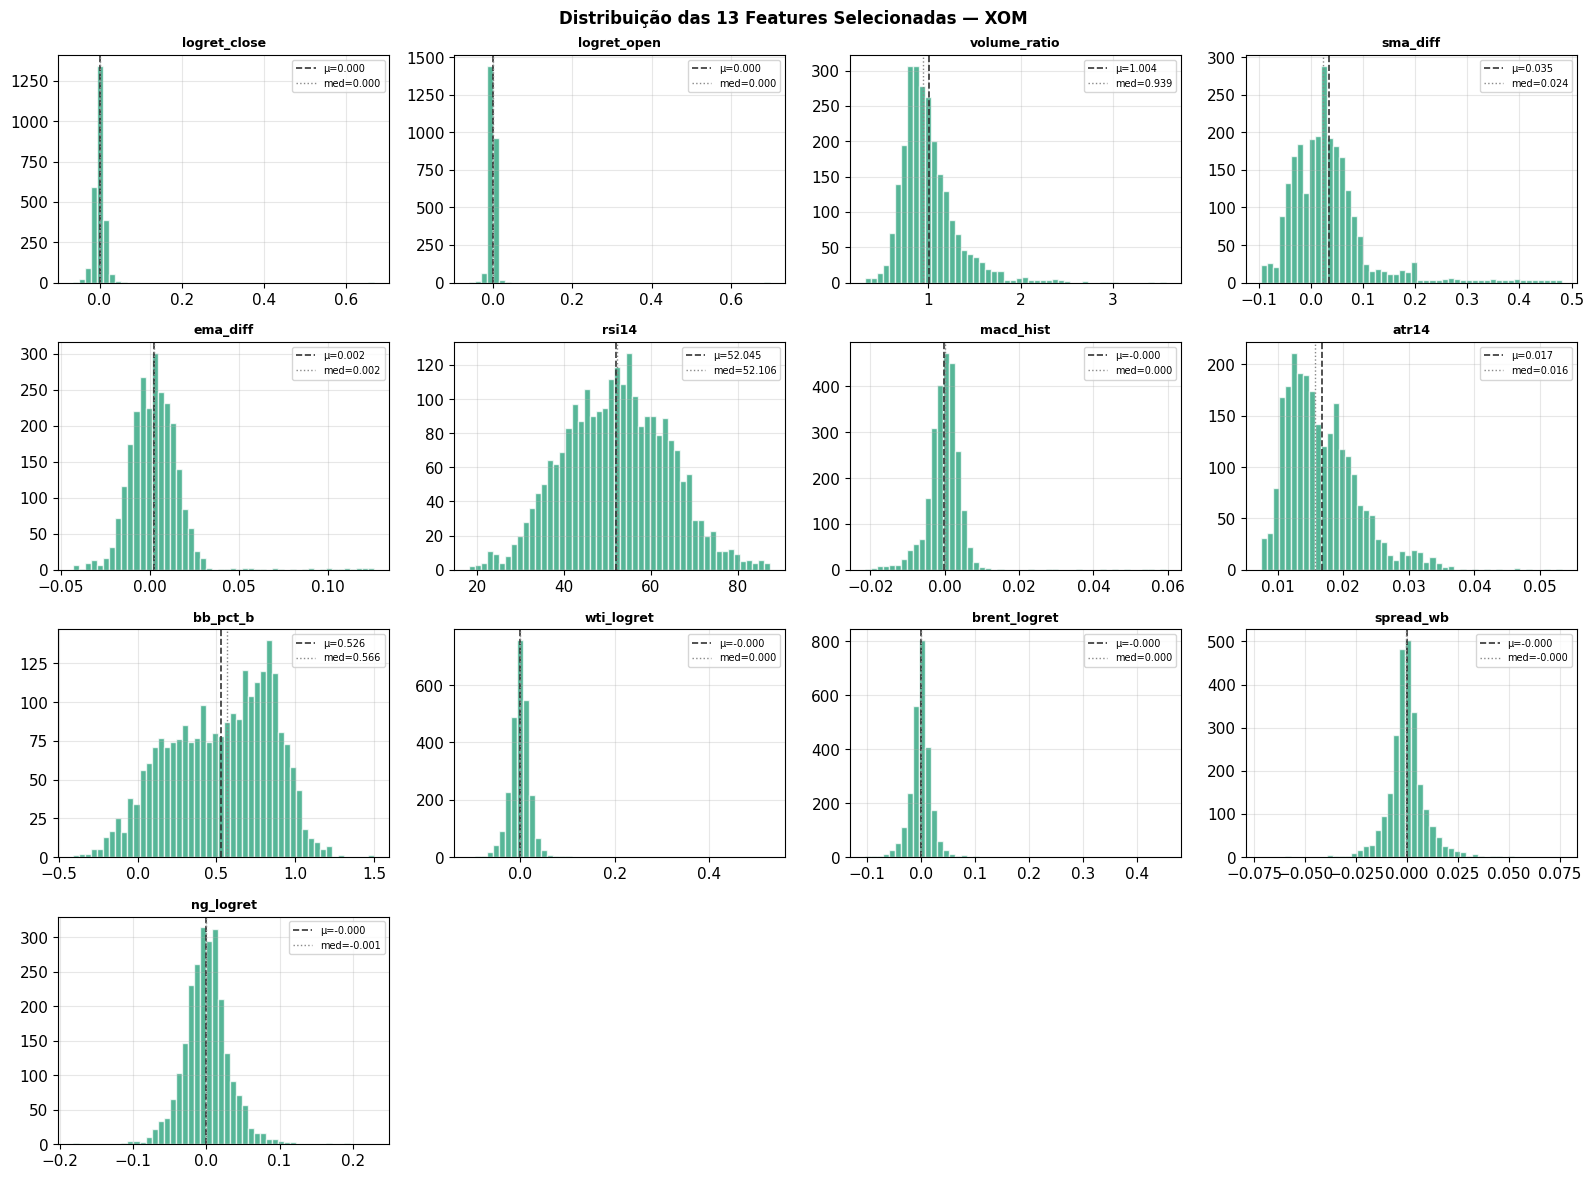

In [12]:
ticker  = 'XOM'
df_plot = features_ativos[ticker][FEATURES_FINAIS]
n_cols  = 4
n_rows  = -(-len(FEATURES_FINAIS) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
fig.suptitle(f'Distribuição das 13 Features Selecionadas — {ticker}',
             fontsize=12, fontweight='bold')

for ax, feat in zip(axes.flat, FEATURES_FINAIS):
    s = df_plot[feat].dropna()
    ax.hist(s, bins=50, color=CORES[ticker], alpha=0.75, edgecolor='white')
    ax.axvline(s.mean(),   color='#333', lw=1.2, ls='--', label=f'μ={s.mean():.3f}')
    ax.axvline(s.median(), color='#888', lw=1.0, ls=':',  label=f'med={s.median():.3f}')
    ax.set_title(feat, fontsize=9, fontweight='bold')
    ax.legend(fontsize=7)

for ax in axes.flat[len(FEATURES_FINAIS):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig(f'distribuicao_features_{ticker}.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
desc = df_plot.describe().T
desc['missing_%'] = df_plot.isnull().mean() * 100
print('=== Estatísticas Descritivas — Features Finais (XOM) ===')
print(desc.round(4).to_string())

=== Estatísticas Descritivas — Features Finais (XOM) ===
               count     mean      std      min      25%      50%      75%      max  missing_%
logret_close  2505.0   0.0003   0.0181  -0.0639  -0.0063   0.0001   0.0068   0.6684        0.0
logret_open   2505.0   0.0001   0.0157  -0.0591  -0.0034   0.0001   0.0036   0.6987        0.0
volume_ratio  2505.0   1.0043   0.3142   0.3134   0.8096   0.9390   1.1233   3.5739        0.0
sma_diff      2505.0   0.0353   0.0819  -0.0957  -0.0163   0.0238   0.0578   0.4815        0.0
ema_diff      2505.0   0.0024   0.0155  -0.0432  -0.0065   0.0020   0.0102   0.1260        0.0
rsi14         2505.0  52.0452  11.9865  18.1614  43.4782  52.1060  60.5353  87.4473        0.0
macd_hist     2505.0  -0.0001   0.0051  -0.0214  -0.0023   0.0001   0.0023   0.0595        0.0
atr14         2505.0   0.0168   0.0056   0.0074   0.0126   0.0156   0.0199   0.0533        0.0
bb_pct_b      2505.0   0.5260   0.3239  -0.4082   0.2677   0.5659   0.7948   1.5020     

---
## 9. Conclusão — Conjunto Final Justificado

In [14]:
print('=' * 70)
print('CONJUNTO FINAL — 13 FEATURES')
print('=' * 70)

justificativas = [
    ('logret_close',  'Preço',     'ADF p<0.05 — estacionária, comparável entre épocas'),
    ('logret_open',   'Preço',     'Gap overnight — surpresas ocorridas fora do pregão'),
    ('volume_ratio',  'Volume',    'Anomalia de participação normalizada entre ativos'),
    ('sma_diff',      'Tendência', 'Regime bull/bear — profecia autorrealizável institucional'),
    ('ema_diff',      'Tendência', 'Tendência curto prazo — complementar à SMA diff'),
    ('rsi14',         'Momentum',  'Sobrecompra/sobrevenda — pandas-ta entrega 0–100'),
    ('macd_hist',     'Momentum',  'Aceleração da tendência — baixa correlação com RSI'),
    ('atr14',         'Volatil.',  'Regime de volatilidade — fundamental para energia'),
    ('bb_pct_b',      'Volatil.',  'Posição no canal — combina tendência + volatilidade'),
    ('wti_logret',    'Macro',     'Driver causal direto de XOM, CVX, SLB e HAL'),
    ('brent_logret',  'Macro',     'Benchmark global — choques geopolíticos internacionais'),
    ('spread_wb',     'Macro',     'Desequilíbrio regional — info além do WTI e Brent'),
    ('ng_logret',     'Macro',     'Gás natural — ciclo nem sempre sincronizado com óleo'),
]

print(f'  {"Feature":<18} {"Grupo":<12} Justificativa')
print(f'  {"-"*17} {"-"*11} {"-"*45}')
for feat, grupo, just in justificativas:
    print(f'  {feat:<18} {grupo:<12} {just}')

print(f'\n  Janela (lookback):       20 passos = 1 mês de pregão')
print(f'  Tensor de entrada LSTM:  (amostras, 20, 13)')

print('\n' + '=' * 70)
print('FEATURES ELIMINADAS — REDUNDÂNCIA (|r| > 0.90)')
print('=' * 70)
for feat, motivo in [
    ('williams_r',          'r > 0.95 com RSI — mesma informação'),
    ('stoch_k / stoch_d',   'coberto conjuntamente por RSI + MACD'),
    ('cci / roc',           'derivados de variáveis já presentes'),
    ('sma20/50/200 brutos',  'substituídos pelo sma_diff normalizado'),
    ('bb_width',            'redundante com atr14 normalizado'),
    ('vol_hist',            'redundante com atr14'),
    ('macd_line',           'redundante com macd_hist'),
    ('obv_diff',            'coberto pelo volume_ratio'),
]:
    print(f'  ✗  {feat:<24}  {motivo}')

CONJUNTO FINAL — 13 FEATURES
  Feature            Grupo        Justificativa
  ----------------- ----------- ---------------------------------------------
  logret_close       Preço        ADF p<0.05 — estacionária, comparável entre épocas
  logret_open        Preço        Gap overnight — surpresas ocorridas fora do pregão
  volume_ratio       Volume       Anomalia de participação normalizada entre ativos
  sma_diff           Tendência    Regime bull/bear — profecia autorrealizável institucional
  ema_diff           Tendência    Tendência curto prazo — complementar à SMA diff
  rsi14              Momentum     Sobrecompra/sobrevenda — pandas-ta entrega 0–100
  macd_hist          Momentum     Aceleração da tendência — baixa correlação com RSI
  atr14              Volatil.     Regime de volatilidade — fundamental para energia
  bb_pct_b           Volatil.     Posição no canal — combina tendência + volatilidade
  wti_logret         Macro        Driver causal direto de XOM, CVX, SLB e HAL
 

In [15]:
# Resumo do dataset final pronto para a LSTM
print('\n=== Dataset Final por Ativo ===')
for ticker in TICKERS_ATIVOS:
    df_f    = features_ativos[ticker][FEATURES_FINAIS + ['target']].dropna()
    n       = len(df_f)
    janelas = n - 20
    print(f'  {ticker}: {n} dias → {janelas} janelas'
          f'  | treino ~{int(janelas*.70)}'
          f'  / val ~{int(janelas*.15)}'
          f'  / teste ~{int(janelas*.15)}')


=== Dataset Final por Ativo ===
  XOM: 2505 dias → 2485 janelas  | treino ~1739  / val ~372  / teste ~372
  CVX: 2505 dias → 2485 janelas  | treino ~1739  / val ~372  / teste ~372
  SLB: 2505 dias → 2485 janelas  | treino ~1739  / val ~372  / teste ~372
  HAL: 2505 dias → 2485 janelas  | treino ~1739  / val ~372  / teste ~372
